1. Initialize:
   - N_observe = fixed number of particles to observe per step (a+b)
   - B = b_total (total budget)
   - Create reward landscape r(x) with values in [0,1]
   - Initialize CNN f_θ(x) for reward prediction (input: coordinates, output: reward [0,1])
   - Define schedules:
     * a(step) and b(step): top/bottom particle selection (a+b=N_observe, early: small a, large b; late: all a)
     * weight_percentile(step): for sampling particles (early: sample middle weights; late: sample extremes)

2. Baseline Diffusion Model:
   - Define equation: ∂q_t/∂t = -⟨∇, q_t(-f_t + σ_t²∇log q_t)⟩ + (σ_t²/2)Δq_t
   - Define SDE: dx_t = (-f_t(x_t) + σ_t²∇log q_t(x_t))dt + σ_t dW_t
   - Use pretrained score function ∇log q_t(x_t)

3. Feynman-Kac Corrector (UPDATED):
   - Diversity Loss: L(x_i) = -∑_{j≠i} ||x_i - x_j||²
   - Modified SDE: 
     dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t))dt - f_t(x_t)dt + γ_t∇L(x_t)dt + σ_t dW_t
   - Weight update: 
     dw_t = (∂β_t/∂t)r(x_t)dt 
            - ⟨β_t∇r(x_t), f_t(x_t)⟩dt 
            + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt
            + ||∇log q_t(x_t) - ∇L(x_t)||₂dt

   Where:
   - γ_t: diversity coefficient (high early → low late)
   - ∇L(x_t): gradient of diversity loss (pushes particles away from clusters)
   - ||∇log q_t - ∇L||₂: conflict between base model and diversity (high in low-prob regions)

4. Cold Start (Step 0):
   - Generate N_observe particles using ONLY baseline diffusion (no FKC)
   - Observe ALL particles (get true rewards)
   - Train CNN with (coordinates, rewards) pairs
   - Budget -= N_observe

5. Main Loop (Step 1 onwards, while B > 0):
   a. Generate N particles using FKC with learned reward gradient from CNN (N is fixed)
   b. Calculate weights w for all particles
   c. Select top k particles by weight (γ_t already manages exploration/exploitation)
   d. Observe true rewards for selected k particles (k is fixed)
   e. Update CNN with new observations (coordinates → actual reward values)
   f. Calculate success rate
   g. Budget -= k
   h. Visualize results

6. Final visualization:
   - Learned reward landscape (from CNN) vs particles (color by weights)
   - True reward landscape vs observed particles (color by true rewards)
   - Success rate evolution

import

In [56]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, Any
import optax
from functools import partial

# Set random seed for reproducibility
jax.config.update("jax_enable_x64", True)

reward

In [57]:
def create_reward_landscape(x: jnp.ndarray) -> jnp.ndarray:
    """
    Create a synthetic reward landscape with values in [0,1].
    This is the 'true' reward function that we're trying to learn.
    """
    # BULLETPROOF: Handle any input shape
    original_shape = x.shape
    
    # Ensure we have a 2D array (batch_size, 2)
    if x.ndim == 1:
        x = x.reshape(-1, 2)
        squeeze_output = True
    elif x.ndim == 2:
        squeeze_output = False
    else:
        # Flatten all but last dimension
        x = x.reshape(-1, x.shape[-1])
        squeeze_output = False
    
    
    # Initialize reward as JAX array with correct shape
    reward = jnp.zeros(x.shape[0])
    
    # Add multiple Gaussian peaks
    peaks = [(0.3, 0.7), (0.7, 0.3), (0.5, 0.5)]
    for peak_x, peak_y in peaks:
        # Calculate distance for each particle
        dist = jnp.sqrt((x[:, 0] - peak_x)**2 + (x[:, 1] - peak_y)**2)
        # Add to reward (both should have shape (batch_size,))
        reward = reward + jnp.exp(-dist**2 / 0.1)
    
    # Ensure [0,1] range
    reward = jnp.clip(reward, 0, 1)
    
    # Reshape back to original shape if needed
    if squeeze_output and original_shape == (2,):
        reward = reward.squeeze()
    elif original_shape != x.shape:
        reward = reward.reshape(original_shape[:-1])
    return reward

def reward_landscape_gradient(x: jnp.ndarray) -> jnp.ndarray:
    """Compute gradient of reward landscape using JAX autodiff."""
    if x.ndim == 1:
        return jax.grad(create_reward_landscape)(x)
    else:
        # For batch of particles, use vmap
        grad_fn = jax.grad(create_reward_landscape)
        return jax.vmap(grad_fn)(x)

def create_four_optima_reward_landscape(x: jnp.ndarray) -> jnp.ndarray:
    """
    Create reward landscape with four global optima in four quadrants.
    Peaks at approximately (0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)
    """
    # BULLETPROOF: Handle any input shape
    original_shape = x.shape
    
    # Ensure we have a 2D array (batch_size, 2)
    if x.ndim == 1:
        x = x.reshape(-1, 2)
        squeeze_output = True
    elif x.ndim == 2:
        squeeze_output = False
    else:
        # Flatten all but last dimension
        x = x.reshape(-1, x.shape[-1])
        squeeze_output = False
    
    
    # Initialize reward as JAX array with correct shape
    reward = jnp.zeros(x.shape[0])
    
    # Four equal peaks in four quadrants
    peaks = [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)]
    for peak_x, peak_y in peaks:
        dist = jnp.sqrt((x[:, 0] - peak_x)**2 + (x[:, 1] - peak_y)**2)
        reward = reward + jnp.exp(-dist**2 / 0.05)  # Narrower peaks
    
    reward = jnp.clip(reward, 0, 1)  # Just clip to [0,1]
    
    # Reshape back to original shape if needed
    if squeeze_output and original_shape == (2,):
        reward = reward.squeeze()
    elif original_shape != x.shape:
        reward = reward.reshape(original_shape[:-1])
    
    return reward

def four_optima_reward_gradient(x: jnp.ndarray) -> jnp.ndarray:
    """Compute gradient of four optima reward landscape."""
    if x.ndim == 1:
        return jax.grad(create_four_optima_reward_landscape)(x)
    else:
        grad_fn = jax.grad(create_four_optima_reward_landscape)
        return jax.vmap(grad_fn)(x)

baseline diffusion model

In [58]:
def baseline_score_function(x: jnp.ndarray, t: float) -> jnp.ndarray:
    """
    Pretrained score function for baseline diffusion.
    MODIFIED: Make this OPPOSITE to the four optima reward to simulate worst case.
    Base model has high probability in CENTER, while rewards are at CORNERS.
    """
    # Instead of 4 peaks at corners, put a single strong peak at center (0.5, 0.5)
    # This is OPPOSITE to the 4-optima reward (corners)
    mean = jnp.array([0.5, 0.5])
    sigma = 0.15  # Narrow peak at center
    
    # Handle both single particle and batch
    if x.ndim == 1:
        score = -(x - mean) / (sigma**2)
    else:  # Batch of particles
        score = -(x - mean[None, :]) / (sigma**2)
    
    return score

def baseline_drift(x: jnp.ndarray, t: float) -> jnp.ndarray:
    """Deterministic drift term f_t(x_t) for baseline diffusion."""
    # Return zeros with the same shape as input
    return jnp.zeros_like(x)

def diffusion_coefficient(t: float) -> float:
    """Time-dependent diffusion coefficient σ_t."""
    return 0.1 * (1 - t)  # Decreases from 0.1 to 0

def baseline_sde_step(x: jnp.ndarray, t: float, dt: float, key: jnp.ndarray) -> jnp.ndarray:
    """
    Single step of baseline SDE: dx_t = (-f_t(x_t) + σ_t²∇log q_t(x_t))dt + σ_t dW_t
    """
    sigma_t = diffusion_coefficient(t)
    score = baseline_score_function(x, t)
    drift = -baseline_drift(x, t) + sigma_t**2 * score
    noise = sigma_t * random.normal(key, x.shape)
    
    # Use absolute value of dt for noise scaling since we go backwards in time
    return x + drift * dt + noise * jnp.sqrt(jnp.abs(dt))  # FIXED: use abs(dt)

In [59]:
def visualize_base_model_distribution():
    """
    Visualize the probability distribution of the base diffusion model.
    Shows where the base model assigns high vs low probability.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    # Create grid
    x_grid = jnp.linspace(0, 1, 100)
    y_grid = jnp.linspace(0, 1, 100)
    X, Y = jnp.meshgrid(x_grid, y_grid)
    grid_points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # Compute log probability using score function
    # Score = ∇log p, so we can integrate or use Gaussian formula directly
    # For Gaussian: log p(x) ∝ -||x - μ||² / (2σ²)
    mean = jnp.array([0.5, 0.5])
    sigma = 0.15
    
    # Compute unnormalized log probability
    distances_sq = jnp.sum((grid_points - mean[None, :])**2, axis=1)
    log_prob = -distances_sq / (2 * sigma**2)
    
    # Convert to probability (exponentiate)
    prob = jnp.exp(log_prob)
    prob = prob.reshape(X.shape)
    
    # Plot
    im = ax.contourf(X, Y, prob, levels=20, cmap='Blues', alpha=0.8)
    plt.colorbar(im, ax=ax, label='Base Model Probability (unnormalized)')
    
    # Mark the peak
    ax.scatter([0.5], [0.5], c='red', s=200, marker='*', 
               edgecolors='black', linewidths=2, 
               label='Base Model Peak (CENTER)', zorder=5)
    
    # Mark the four reward peaks (corners)
    reward_peaks = [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)]
    for px, py in reward_peaks:
        ax.scatter([px], [py], c='yellow', s=150, marker='o', 
                   edgecolors='black', linewidths=2, alpha=0.7, zorder=5)
    
    ax.scatter([], [], c='yellow', s=150, marker='o', 
               edgecolors='black', linewidths=2, alpha=0.7,
               label='Reward Peaks (CORNERS)')
    
    ax.set_title('BASE MODEL Distribution vs REWARD Peaks\n(Opposite Scenario)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    print("="*80)
    print("BASE MODEL vs REWARD DISTRIBUTION")
    print("="*80)
    print("Base Model: Gaussian centered at (0.5, 0.5) with σ=0.15")
    print("  → HIGH probability at CENTER")
    print("  → LOW probability at corners")
    print("\nReward Function: Four peaks at corners")
    print("  → HIGH reward at (0.25,0.25), (0.75,0.25), (0.25,0.75), (0.75,0.75)")
    print("  → LOW reward at center")
    print("\nThis is a WORST CASE scenario: rewards are where base model has low prob!")
    print("="*80 + "\n")

feynman-kac corrector

In [60]:
def compute_pairwise_distance_loss(x: jnp.ndarray, particle_idx: int) -> float:
    """
    Compute diversity loss for a single particle: L(x_i) = -∑_{j≠i} ||x_i - x_j||²
    
    Args:
        x: All particles (n_particles, 2)
        particle_idx: Index of the particle to compute loss for
    
    Returns:
        loss: Scalar loss value (negative sum of squared distances)
    """
    x_i = x[particle_idx]
    # Compute squared distances to all other particles
    distances_sq = jnp.sum((x - x_i[None, :])**2, axis=1)
    # Exclude self (distance to itself is 0)
    # mask = jnp.arange(len(x)) != particle_idx
    # Return negative sum (so gradient pushes away from clusters)
    #return jnp.sum(distances_sq * mask)
    return jnp.sum(distances_sq)


def compute_diversity_loss_gradient_with_history(x: jnp.ndarray, 
                                                   historical_particles: jnp.ndarray = None) -> jnp.ndarray:
    """
    UPDATED: Vectorized diversity loss gradient computation with historical particle consideration.
    
    Diversity loss for particle i: L(x_i) = -∑_{j≠i} ||x_i - x_j||²
    where j includes both current batch particles AND all historical observed particles.
    
    Gradient: ∇L(x_i) = -2∑_{j≠i} (x_i - x_j)
    
    NORMALIZATION: Divide by total number of particles to keep magnitude comparable
    to reward/score gradients.
    
    Args:
        x: Current batch particles (n_particles, 2)
        historical_particles: All previously observed particles (n_historical, 2) or None
    
    Returns:
        gradients: (n_particles, 2) normalized gradients for each particle
    """
    n_current = x.shape[0]
    
    # Compute gradient from current batch particles
    # differences[i, j] = x[i] - x[j]
    differences_current = x[:, None, :] - x[None, :, :]
    grad_current = 2 * jnp.sum(differences_current, axis=1)  # Sum over j dimension
    
    # Add contribution from historical particles if provided
    if historical_particles is not None and len(historical_particles) > 0:
        # For each current particle, compute distance to all historical particles
        # x: (n_current, 2), historical: (n_historical, 2)
        # differences_hist[i, j] = x[i] - historical[j]
        differences_hist = x[:, None, :] - historical_particles[None, :, :]
        grad_historical = 2 * jnp.sum(differences_hist, axis=1)  # Sum over historical particles
        
        # Total gradient combines both terms
        grad = grad_current + grad_historical
        
        # Normalize by total number of particles considered
        total_particles = n_current + len(historical_particles)
        grad = grad / total_particles
    else:
        # Only current batch particles
        grad = grad_current / n_current
    
    return grad


def gamma_schedule(step: int, total_steps: int, gamma_max: float = 0.05, gamma_min: float = 0.0) -> float:
    """
    CORRECTED: Diversity coefficient decreases across BUDGET STEPS, not diffusion time.
    
    Args:
        step: Current budget step (0, 1, 2, ...)
        total_steps: Total number of budget steps
        gamma_max: Maximum gamma at step 0 (high diversity/exploration)
        gamma_min: Minimum gamma at final step (low diversity/exploitation)
    
    Returns:
        gamma_t: Diversity coefficient for this step
    """
    if total_steps <= 1:
        return gamma_max
    
    progress = step / (total_steps - 1)  # 0.0 at start → 1.0 at end
    # Linear decay: high gamma early, low gamma late
    return gamma_max * (1 - progress) + gamma_min * progress

In [61]:
def feynman_kac_sde_step(x: jnp.ndarray, w: jnp.ndarray, t: float, dt: float, 
                         reward_grad_fn, beta_t: float, gamma_t: float, 
                         key: jnp.ndarray, network, network_params,
                         historical_particles: jnp.ndarray = None) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    SIMPLIFIED: Core FKC terms + gamma-controlled diversity-score alignment.
    
    Weight update:
    - term1: reward accumulation (dominant)
    - term2: reward-drift interaction
    - term3: reward-score alignment from FKC theory (dominant)
    - term6: diversity-score alignment controlled by gamma_t
    
    Args:
        historical_particles: Previously observed particles for diversity computation
    """
    sigma_t = diffusion_coefficient(t)
    score = baseline_score_function(x, t)  # ∇log q_t (base model)
    reward_grad = reward_grad_fn(x)
    
    # Compute diversity loss gradient WITH HISTORICAL PARTICLES
    diversity_grad = compute_diversity_loss_gradient_with_history(x, historical_particles)
    
    # SDE drift (unchanged)
    drift = (sigma_t**2 * (score + (beta_t / 2) * reward_grad) 
             - baseline_drift(x, t) 
             + gamma_t * diversity_grad)
        
    noise = sigma_t * random.normal(key, x.shape)
    x_new = x + drift * dt + noise * jnp.sqrt(jnp.abs(dt))
    
    # SIMPLIFIED Weight equation - only core FKC terms + diversity-score alignment
    predicted_reward = network['forward'](network_params, x)
    beta_dot = 1.0
    dt_abs = jnp.abs(dt)
    
    if x.ndim == 2:  # Batch of particles
        # Term 1: Predicted reward contribution (DOMINANT)
        term1 = beta_dot * predicted_reward * dt_abs
        
        # Term 2: Reward-drift interaction
        f_t = baseline_drift(x, t)
        term2 = -jnp.sum(beta_t * reward_grad * f_t, axis=1) * dt_abs
        
        # Term 3: Reward-score alignment from FKC theory (DOMINANT)
        term3 = jnp.sum(beta_t * reward_grad * (sigma_t**2 / 2) * score, axis=1) * dt_abs
        
        # Term 6: Diversity-Score alignment controlled by gamma_t
        # ⟨∇L, ∇log p⟩ with strength controlled by gamma (same schedule as diversity)
        # POSITIVE when diversity explores toward high base prob (GOOD)
        # NEGATIVE when diversity pushes to low base prob (BAD)
        term6 = gamma_t * jnp.sum(diversity_grad * score, axis=1) * dt_abs
        
        dw = term1 + term2 + term3 + term6
        
    else:  # Single particle
        term1 = beta_dot * predicted_reward * dt_abs
        
        f_t = baseline_drift(x, t)
        term2 = -jnp.dot(beta_t * reward_grad, f_t) * dt_abs
        
        term3 = jnp.dot(beta_t * reward_grad, (sigma_t**2 / 2) * score) * dt_abs
        
        term6 = gamma_t * jnp.dot(diversity_grad, score) * dt_abs
        
        dw = term1 + term2 + term3 + term6
    
    # Clip and update weights
    dw = jnp.clip(dw, -1.0, 1.0)
    w_new = w + dw
    w_new = jnp.clip(w_new, -100.0, 100.0)
    
    return x_new, w_new


def run_fkc_simulation(particles: jnp.ndarray, weights: jnp.ndarray, 
                      reward_grad_fn, beta_t: float, gamma_t: float,
                      n_steps: int, key: jnp.ndarray,
                      network, network_params,
                      historical_particles: jnp.ndarray = None) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    UPDATED: Passes historical particles to FKC step and normalizes weights to [0, 1] after trajectory.
    
    Args:
        gamma_t: Diversity coefficient (constant for this trajectory)
        historical_particles: All previously observed particles for diversity computation
        ... (other args)
    """
    dt = -1.0 / n_steps
    
    for i in range(n_steps):
        t = 1.0 + i * dt
        key, subkey = random.split(key)
        
        particles, weights = feynman_kac_sde_step(
            particles, weights, t, dt, 
            reward_grad_fn, beta_t, gamma_t,
            subkey, network, network_params,
            historical_particles=historical_particles  # Pass historical particles
        )
        
        # Numerical stability checks
        if jnp.any(jnp.isnan(weights)) or jnp.any(jnp.isinf(weights)):
            weights = jnp.where(jnp.isnan(weights) | jnp.isinf(weights), 1.0, weights)
        
        if jnp.any(jnp.isnan(particles)) or jnp.any(jnp.isinf(particles)):
            print(f"  WARNING: NaN particles detected at step {i}, clipping...")
            particles = jnp.where(jnp.isnan(particles) | jnp.isinf(particles), 
                                jnp.clip(particles, 0, 1), particles)
    
    # ========== NORMALIZE WEIGHTS TO [0, 1] ==========
    w_min = jnp.min(weights)
    w_max = jnp.max(weights)
    
    if w_max - w_min > 1e-8:  # Avoid division by zero
        weights = (weights - w_min) / (w_max - w_min)
    else:
        weights = jnp.ones_like(weights) * 0.5
    
    # Verify weights are in [0, 1]
    assert jnp.all(weights >= 0) and jnp.all(weights <= 1), "Weights must be in [0, 1]"
    
    return particles, weights

reward learning neural network

In [62]:
def create_cnn_reward_network():
    """
    Create a CNN for reward prediction that treats 2D coordinates as spatial features.
    """
    def init_fn(key):
        """Initialize CNN parameters."""
        params = {}
        
        # Feature expansion layer: 2 -> 32
        key, subkey = random.split(key)
        params['expand_W'] = random.normal(subkey, (2, 32)) * 0.1
        params['expand_b'] = jnp.zeros(32)
        
        # Conv layers (we'll simulate with dense layers on feature representations)
        key, subkey = random.split(key)
        params['conv1_W'] = random.normal(subkey, (32, 64)) * 0.1
        params['conv1_b'] = jnp.zeros(64)
        
        key, subkey = random.split(key)
        params['conv2_W'] = random.normal(subkey, (64, 64)) * 0.1
        params['conv2_b'] = jnp.zeros(64)
        
        # Fully connected layers
        key, subkey = random.split(key)
        params['fc1_W'] = random.normal(subkey, (64, 32)) * 0.1
        params['fc1_b'] = jnp.zeros(32)
        
        key, subkey = random.split(key)
        params['fc2_W'] = random.normal(subkey, (32, 1)) * 0.1
        params['fc2_b'] = jnp.zeros(1)
        
        return params
    
    def forward(params, x):
        """Forward pass through CNN."""
        # Handle both single particle and batch
        if x.ndim == 1:
            x = x.reshape(1, -1)
            squeeze_output = True
        else:
            squeeze_output = False
        
        # Feature expansion
        h = jnp.dot(x, params['expand_W']) + params['expand_b']
        h = jax.nn.relu(h)
        
        # Conv-like layer 1
        h = jnp.dot(h, params['conv1_W']) + params['conv1_b']
        h = jax.nn.relu(h)
        
        # Conv-like layer 2
        h = jnp.dot(h, params['conv2_W']) + params['conv2_b']
        h = jax.nn.relu(h)
        
        # Fully connected layer 1
        h = jnp.dot(h, params['fc1_W']) + params['fc1_b']
        h = jax.nn.relu(h)
        
        # Output layer: predict actual reward value [0,1]
        h = jnp.dot(h, params['fc2_W']) + params['fc2_b']
        h = jax.nn.sigmoid(h)  # Output in [0,1]
        
        
        # CRITICAL FIX: Ensure output is 1D for batch inputs
        if h.ndim > 1 and h.shape[-1] == 1:
            h = h.squeeze(-1)  # Remove the last dimension if it's 1
        
        if squeeze_output:
            h = h.squeeze()
        
        
        return h
    
    return {'init': init_fn, 'forward': forward}

def update_network(network, params, optimizer, opt_state, x_batch, y_batch):
    """Update neural network parameters using observed rewards."""
    def loss_fn(params):
        predictions = network['forward'](params, x_batch)
        
        # Ensure shapes match
        if predictions.shape != y_batch.shape:
            if predictions.ndim > y_batch.ndim:
                # Remove extra dimensions
                while predictions.ndim > y_batch.ndim:
                    predictions = predictions.squeeze(-1)
            elif predictions.ndim < y_batch.ndim:
                # Add missing dimensions
                while predictions.ndim < y_batch.ndim:
                    predictions = predictions.unsqueeze(-1)
        
        # MSE loss on actual reward values [0,1]
        return jnp.mean((predictions - y_batch)**2)
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

def reward_network_gradient(network, params, x):
    """Compute gradient of reward network using JAX autodiff with numerical stability."""
    # For vectorized inputs, we need to compute gradients for each particle
    if x.ndim == 2:  # Batch of particles
        # Use vmap to vectorize the gradient computation
        grad_fn = jax.grad(lambda single_x: network['forward'](params, single_x))
        grad = jax.vmap(grad_fn)(x)
    else:  # Single particle
        grad = jax.grad(lambda single_x: network['forward'](params, single_x))(x)
    
    # Add numerical stability: clip gradients to prevent extreme values
    grad = jnp.clip(grad, -10.0, 10.0)
    
    # Check for NaN values and replace with zeros
    grad = jnp.where(jnp.isnan(grad) | jnp.isinf(grad), 0.0, grad)
    
    return grad

main algorithm

In [63]:
def budget_constrained_diffusion(k_observe: int, B: int, 
                                n_particles: int = 200,
                                n_steps: int = 100, 
                                reward_fn = None,
                                network = None,
                                network_params = None,
                                opt_state = None):
    """
    FIXED: Train CNN on ALL historical observations to prevent catastrophic forgetting.
    """
    if reward_fn is None:
        raise ValueError("Must provide a reward_fn")
    
    if k_observe > n_particles:
        raise ValueError("k_observe must be <= n_particles")
    
    # Initialize
    key = random.PRNGKey(42)
    
    # Network setup
    if network is None:
        network = create_cnn_reward_network()
        key, subkey = random.split(key)
        network_params = network['init'](subkey)
        optimizer = optax.adam(learning_rate=0.01)
        opt_state = optimizer.init(network_params)
        print("  Created new neural network")
    else:
        optimizer = optax.adam(learning_rate=0.01)
        if opt_state is None:
            opt_state = optimizer.init(network_params)
        print("  Using pre-trained neural network (continuing training)")
    
    # Storage for results
    all_particles = []
    all_weights = []
    all_observed_particles = []
    all_observed_rewards = []
    success_rates = []
    gamma_history = []
    
    # Track ALL historical observed particles AND their rewards
    historical_particles_list = []
    historical_rewards_list = []  # NEW: also store rewards
    
    # Estimate total steps
    total_steps = B // k_observe
    step_count = 0
    
    # === COLD START (Step 0) ===
    print(f"Step {step_count} [COLD START], Budget remaining: {B}")
    
    key, subkey = random.split(key)
    particles = random.uniform(subkey, (k_observe, 2))
    
    dt = -1.0 / n_steps
    for i in range(n_steps):
        t = 1.0 + i * dt
        key, subkey = random.split(key)
        particles = baseline_sde_step(particles, t, dt, subkey)
    
    particles = jnp.clip(particles, 0, 1)
    observed_particles = particles
    observed_rewards = reward_fn(observed_particles)
    
    # Add to historical data
    historical_particles_list.append(observed_particles)
    historical_rewards_list.append(observed_rewards)
    
    # Train on all historical data (just this batch for now)
    all_historical_particles = jnp.concatenate(historical_particles_list, axis=0)
    all_historical_rewards = jnp.concatenate(historical_rewards_list, axis=0)
    
    print(f"  Training CNN on {len(all_historical_particles)} total observations...")
    for epoch in range(50):
        network_params, opt_state, loss = update_network(
            network, network_params, optimizer, opt_state,
            all_historical_particles, all_historical_rewards  # ALL historical data
        )
    print(f"    Final training loss: {loss:.6f}")
    
    success_rate = jnp.mean((observed_rewards > 0.7).astype(float))
    success_rates.append(success_rate)
    
    all_particles.append(particles)
    all_weights.append(jnp.ones(len(particles)))
    all_observed_particles.append(observed_particles)
    all_observed_rewards.append(observed_rewards)
    
    B -= k_observe
    step_count += 1
    
    visualize_step(step_count, particles, jnp.ones(len(particles)), observed_particles, 
                  observed_rewards, success_rates, network, network_params, reward_fn)
    
    # === MAIN LOOP (Step 1 onwards) ===
    while B > 0:
        print(f"Step {step_count}, Budget remaining: {B}")
        
        # Compute gamma for this budget step
        current_gamma = gamma_schedule(step_count - 1, total_steps, gamma_max=0.05, gamma_min=0.0)
        print(f"  Gamma for this step: {current_gamma:.4f}")
        
        # Concatenate all historical particles (for diversity)
        historical_particles = jnp.concatenate(historical_particles_list, axis=0)
        print(f"  Using {len(historical_particles)} historical particles for diversity computation")
        
        # Generate particles
        key, subkey = random.split(key)
        particles = random.uniform(subkey, (n_particles, 2))
        weights = jnp.zeros(n_particles)
        
        def reward_grad_fn(x):
            return reward_network_gradient(network, network_params, x)
        
        # Run FKC with FIXED gamma and historical particles
        particles, weights = run_fkc_simulation(
            particles, weights, 
            reward_grad_fn,
            beta_t=1.0,
            gamma_t=current_gamma,
            n_steps=n_steps,
            key=subkey,
            network=network,
            network_params=network_params,
            historical_particles=historical_particles
        )
        
        # Store gamma
        gamma_history.append(current_gamma)
        
        # Selection
        sorted_indices = jnp.argsort(weights)
        observe_indices = sorted_indices[-k_observe:]
        
        selected_weights = weights[observe_indices]
        print(f"    Selected weight range: [{jnp.min(selected_weights):.3f}, {jnp.max(selected_weights):.3f}]")
        print(f"    All particles weight range: [{jnp.min(weights):.3f}, {jnp.max(weights):.3f}]")
        
        # Observe true rewards
        observed_particles = particles[observe_indices]
        observed_rewards = reward_fn(observed_particles)
        
        # Add to historical data
        historical_particles_list.append(observed_particles)
        historical_rewards_list.append(observed_rewards)
        
        success_rate = jnp.mean((observed_rewards > 0.7).astype(float))
        success_rates.append(success_rate)
        
        # CRITICAL FIX: Train on ALL historical observations, not just current batch
        all_historical_particles = jnp.concatenate(historical_particles_list, axis=0)
        all_historical_rewards = jnp.concatenate(historical_rewards_list, axis=0)
        
        print(f"  Training CNN on {len(all_historical_particles)} total observations...")
        for epoch in range(50):
            network_params, opt_state, loss = update_network(
                network, network_params, optimizer, opt_state,
                all_historical_particles, all_historical_rewards  # ALL historical data
            )
        print(f"    Final training loss: {loss:.6f}")
        
        # Store results
        all_particles.append(particles)
        all_weights.append(weights)
        all_observed_particles.append(observed_particles)
        all_observed_rewards.append(observed_rewards)
        
        # Update budget
        n_to_observe = min(k_observe, B)
        B -= n_to_observe
        step_count += 1
        
        # Visualize
        visualize_step(step_count, particles, weights, observed_particles, 
                      observed_rewards, success_rates, network, network_params, reward_fn)
    
    # Return results
    return (all_particles, all_weights, all_observed_particles, all_observed_rewards, 
            success_rates, network, network_params, opt_state, gamma_history)

visualization

In [64]:
def visualize_step(step: int, particles: jnp.ndarray, weights: jnp.ndarray, 
                  observed_particles: jnp.ndarray, observed_rewards: jnp.ndarray,
                  success_rates: list, network: Dict, network_params: Dict,
                  reward_fn):
    """
    Visualize results for current step.
    
    Plot 1: CNN learned reward landscape + all generated particles (colored by weight) + selected particles (circled)
    Plot 2: True reward landscape + observed particles (colored by actual reward - continuous)
    Plot 3: Success rate evolution
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Create grid for landscape visualization
    x_grid = jnp.linspace(0, 1, 100)
    y_grid = jnp.linspace(0, 1, 100)
    X, Y = jnp.meshgrid(x_grid, y_grid)
    grid_points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # === PLOT 1: CNN Learned Reward + All Particles (colored by weight) + Selected Particles (circled) ===
    # Get CNN learned rewards for grid
    learned_rewards = network['forward'](network_params, grid_points)
    learned_rewards = learned_rewards.reshape(X.shape)
    
    # Plot learned reward landscape
    im1 = axes[0].contourf(X, Y, learned_rewards, levels=20, cmap='viridis', alpha=0.4)
    plt.colorbar(im1, ax=axes[0], label='Learned Reward')
    
    # Plot all generated particles colored by their weights
    valid_particles = ~jnp.isnan(particles).any(axis=1)
    valid_weights = weights[valid_particles]
    valid_particles_coords = particles[valid_particles]
    
    if len(valid_particles_coords) > 0:
        # Use a colormap to show weight distribution
        scatter_all = axes[0].scatter(
            valid_particles_coords[:, 0], 
            valid_particles_coords[:, 1],
            c=valid_weights,  # Color by weight
            cmap='plasma',  # Different colormap from landscape
            s=30, 
            alpha=0.6,
            vmin=jnp.min(valid_weights),
            vmax=jnp.max(valid_weights),
            edgecolors='none',
            label=f'All particles (n={len(valid_particles_coords)})'
        )
        # Add colorbar for particle weights
        cbar_weights = plt.colorbar(scatter_all, ax=axes[0], label='Particle Weight', 
                                    orientation='horizontal', pad=0.05, aspect=30)
    
    # Circle the selected/observed particles with thick black edges
    if len(observed_particles) > 0:
        axes[0].scatter(
            observed_particles[:, 0], 
            observed_particles[:, 1],
            s=150,  # Larger size
            facecolors='none',  # Transparent fill
            edgecolors='red',  # Red edge
            linewidths=2.5,  # Thick edge
            marker='o',
            label=f'Selected (n={len(observed_particles)})'
        )
    
    axes[0].set_title(f'Step {step}: CNN Learned Reward\n+ All Particles (colored by weight) + Selected (red circles)')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    
    # === PLOT 2: True Reward + Observed Particles (color by actual reward - continuous) ===
    # Get true rewards for grid
    true_rewards = reward_fn(grid_points)
    true_rewards = true_rewards.reshape(X.shape)
    
    # Plot true reward landscape
    im2 = axes[1].contourf(X, Y, true_rewards, levels=20, cmap='viridis', alpha=0.6)
    plt.colorbar(im2, ax=axes[1], label='True Reward')
    
    # Plot observed particles colored by their ACTUAL REWARD VALUE (continuous)
    if len(observed_particles) > 0:
        scatter = axes[1].scatter(
            observed_particles[:, 0], 
            observed_particles[:, 1],
            c=observed_rewards,  # Color by actual reward value
            cmap='RdYlGn',  # Red (low) to Yellow to Green (high)
            s=100, 
            alpha=0.9, 
            marker='o', 
            edgecolors='black', 
            linewidths=1.5,
            vmin=0, 
            vmax=1,  # Reward range [0,1]
            label=f'Observed (n={len(observed_particles)})'
        )
        # Add colorbar for observed rewards
        cbar_scatter = plt.colorbar(scatter, ax=axes[1], label='Observed Reward Value', 
                                   orientation='horizontal', pad=0.1, aspect=30)
    
    axes[1].set_title(f'Step {step}: True Reward Landscape\n+ Observed Particles (Colored by Actual Reward)')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    
    # === PLOT 3: Success Rate Evolution ===
    axes[2].plot(range(1, len(success_rates) + 1), success_rates, 'b-o', linewidth=2, markersize=6)
    axes[2].set_title('Success Rate Evolution')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('Success Rate')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1)
    axes[2].axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='Target (0.7)')
    axes[2].legend(loc='lower right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print vital statistics only
    if len(observed_particles) > 0:
        success_threshold = 0.7
        n_success = jnp.sum(observed_rewards > success_threshold)
        avg_reward = jnp.mean(observed_rewards)
        
        print(f"Step {step}: Observed {len(observed_particles)} particles | "
              f"Avg Reward: {avg_reward:.3f} | "
              f"Success: {n_success}/{len(observed_particles)} ({success_rates[-1]:.1%})")

In [65]:
def visualize_gamma_and_diversity(gamma_history, all_weights, k_observe):
    """
    Visualize gamma schedule and weight distribution evolution.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    steps = range(1, len(gamma_history) + 1)
    
    # Plot 1: Gamma schedule over time
    axes[0, 0].plot(steps, gamma_history, 'b-o', linewidth=2, markersize=6)
    axes[0, 0].set_title('Gamma Schedule (Diversity Coefficient)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Step', fontsize=12)
    axes[0, 0].set_ylabel('Gamma', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, max(gamma_history) * 1.1 if max(gamma_history) > 0 else 0.1)
    
    # Plot 2: Weight distribution evolution (box plot)
    weight_data = [w for w in all_weights[1:]]  # Skip cold start
    axes[0, 1].boxplot(weight_data, positions=steps)
    axes[0, 1].set_title('Weight Distribution Evolution', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Step', fontsize=12)
    axes[0, 1].set_ylabel('Weight Value', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Mean and std of weights over time
    mean_weights = [jnp.mean(w) for w in all_weights[1:]]
    std_weights = [jnp.std(w) for w in all_weights[1:]]
    
    axes[1, 0].plot(steps, mean_weights, 'o-', color='blue', linewidth=2, markersize=6, label='Mean')
    axes[1, 0].fill_between(steps, 
                            np.array(mean_weights) - np.array(std_weights),
                            np.array(mean_weights) + np.array(std_weights),
                            alpha=0.3, color='blue', label='±1 Std')
    axes[1, 0].set_title('Weight Statistics', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Step', fontsize=12)
    axes[1, 0].set_ylabel('Weight Value', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: REMOVED (was selection threshold)
    # NEW: Weight range evolution (min/max)
    min_weights = [jnp.min(w) for w in all_weights[1:]]
    max_weights = [jnp.max(w) for w in all_weights[1:]]
    
    axes[1, 1].plot(steps, max_weights, 'o-', color='green', linewidth=2, markersize=6, label='Max Weight')
    axes[1, 1].plot(steps, min_weights, 'o-', color='red', linewidth=2, markersize=6, label='Min Weight')
    axes[1, 1].fill_between(steps, min_weights, max_weights, alpha=0.2, color='gray')
    axes[1, 1].set_title('Weight Range Evolution', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Step', fontsize=12)
    axes[1, 1].set_ylabel('Weight Value', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*80)
    print("DIVERSITY-BASED EXPLORATION SUMMARY")
    print("="*80)
    print(f"Total steps (excluding cold start): {len(gamma_history)}")
    print(f"Gamma range: [{min(gamma_history):.3f}, {max(gamma_history):.3f}]")
    print(f"Final gamma: {gamma_history[-1]:.3f}")
    print(f"Always selected top-{k_observe} particles by weight")
    print("="*80 + "\n")

run

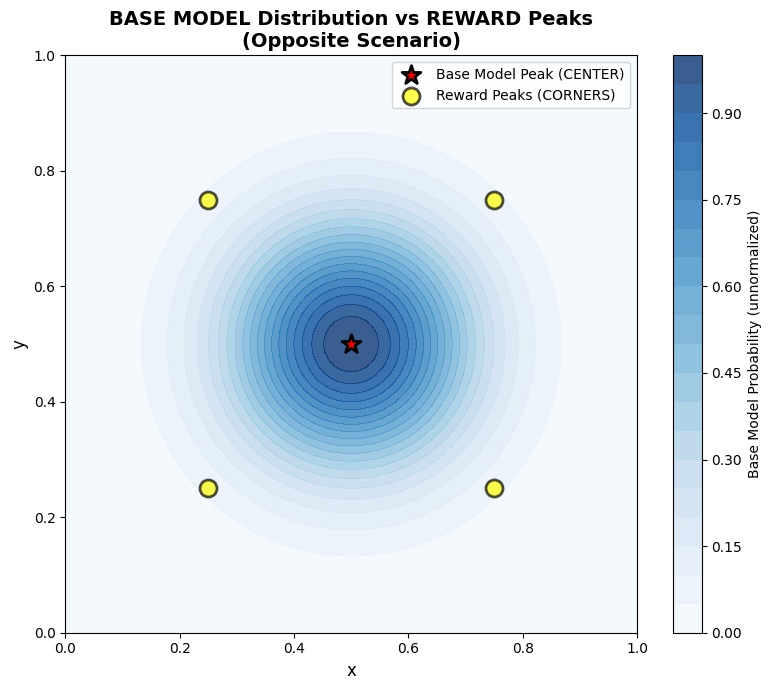

BASE MODEL vs REWARD DISTRIBUTION
Base Model: Gaussian centered at (0.5, 0.5) with σ=0.15
  → HIGH probability at CENTER
  → LOW probability at corners

Reward Function: Four peaks at corners
  → HIGH reward at (0.25,0.25), (0.75,0.25), (0.25,0.75), (0.75,0.75)
  → LOW reward at center

This is a WORST CASE scenario: rewards are where base model has low prob!

TESTING: Base Model OPPOSITE to Reward (Worst Case Scenario)

Base model: Gaussian peak at CENTER (0.5, 0.5)
Reward function: Four peaks at CORNERS (0.25, 0.25), etc.

  Created new neural network
Step 0 [COLD START], Budget remaining: 500
  Training CNN on 50 total observations...
    Final training loss: 0.017277


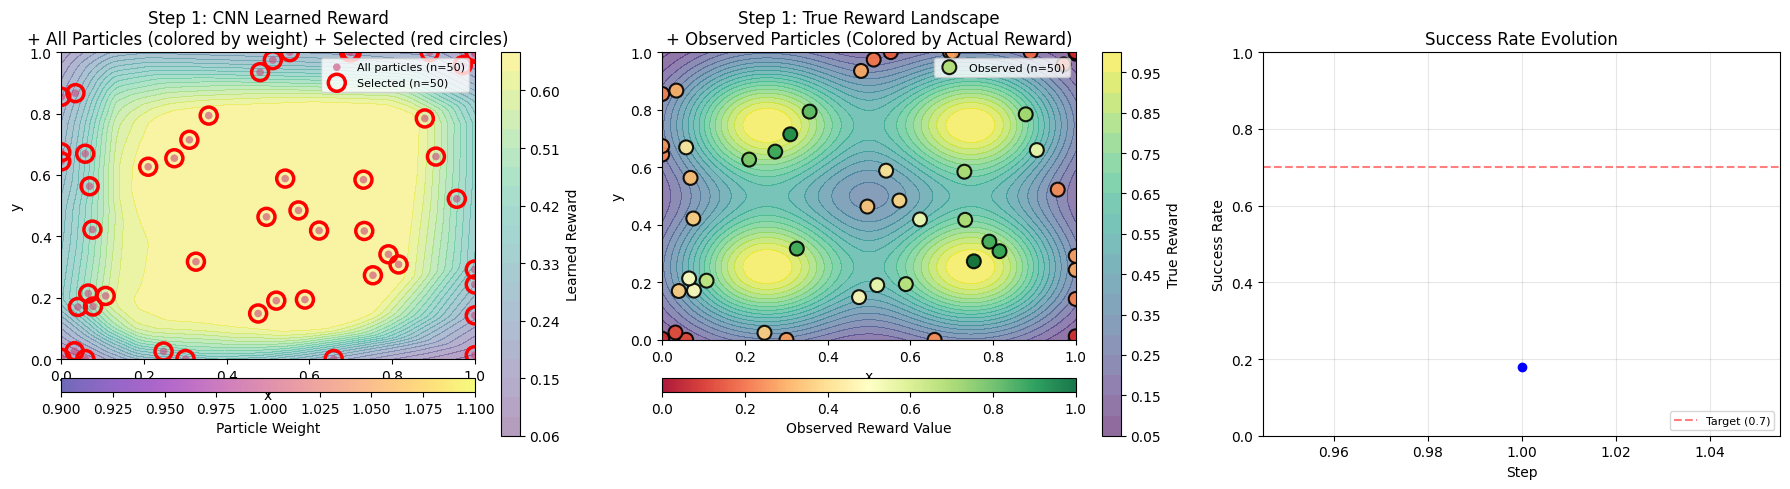

Step 1: Observed 50 particles | Avg Reward: 0.425 | Success: 9/50 (18.0%)
Step 1, Budget remaining: 450
  Gamma for this step: 0.0500
  Using 50 historical particles for diversity computation
    Selected weight range: [0.872, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 100 total observations...
    Final training loss: 0.009822


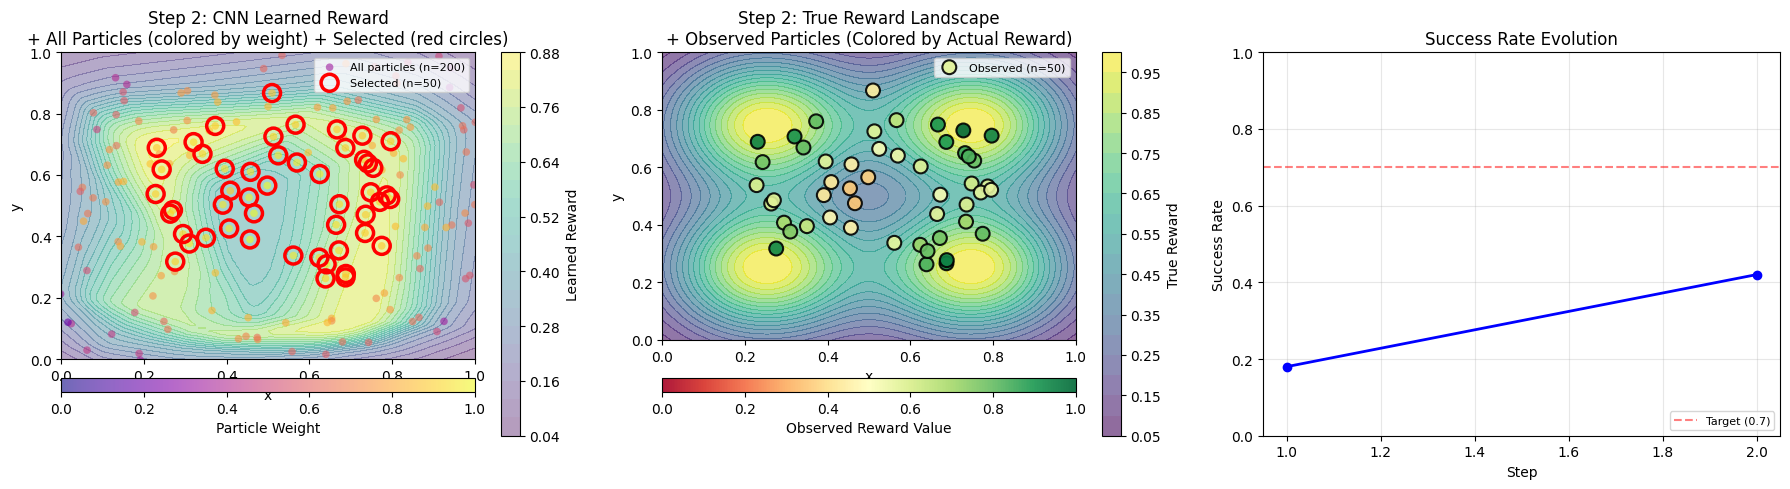

Step 2: Observed 50 particles | Avg Reward: 0.670 | Success: 21/50 (42.0%)
Step 2, Budget remaining: 400
  Gamma for this step: 0.0444
  Using 100 historical particles for diversity computation
    Selected weight range: [0.917, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 150 total observations...
    Final training loss: 0.001843


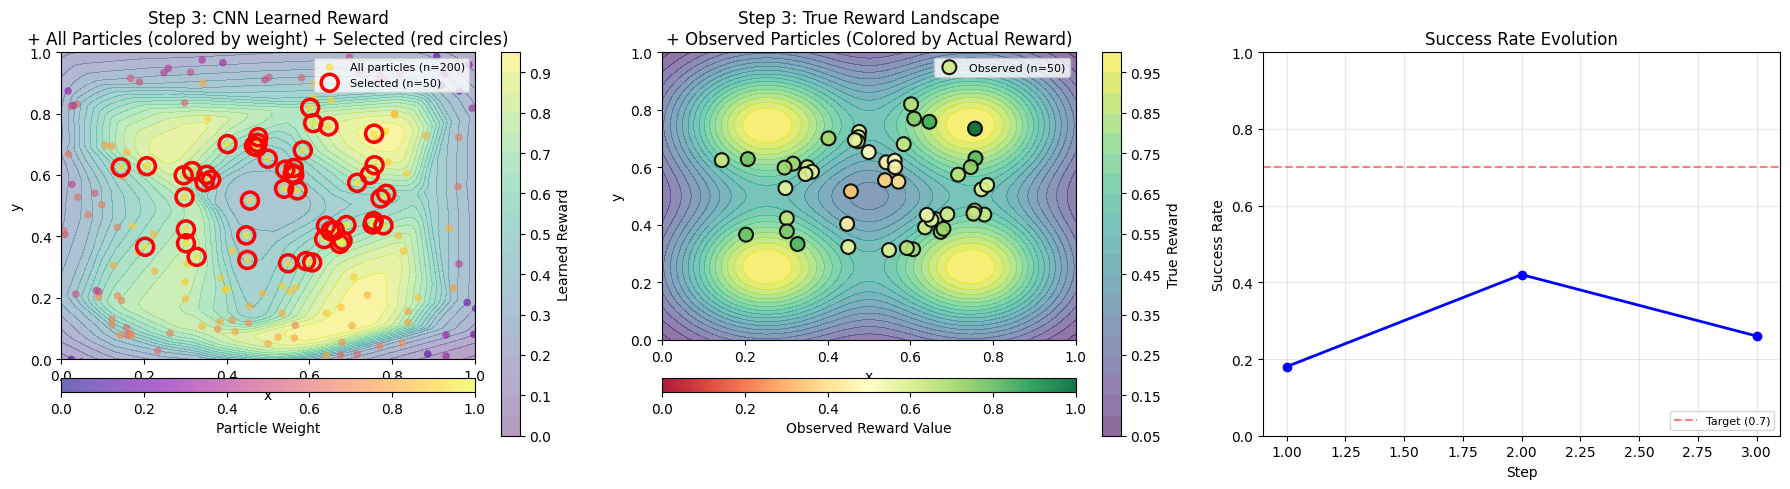

Step 3: Observed 50 particles | Avg Reward: 0.623 | Success: 13/50 (26.0%)
Step 3, Budget remaining: 350
  Gamma for this step: 0.0389
  Using 150 historical particles for diversity computation
    Selected weight range: [0.910, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 200 total observations...
    Final training loss: 0.000604


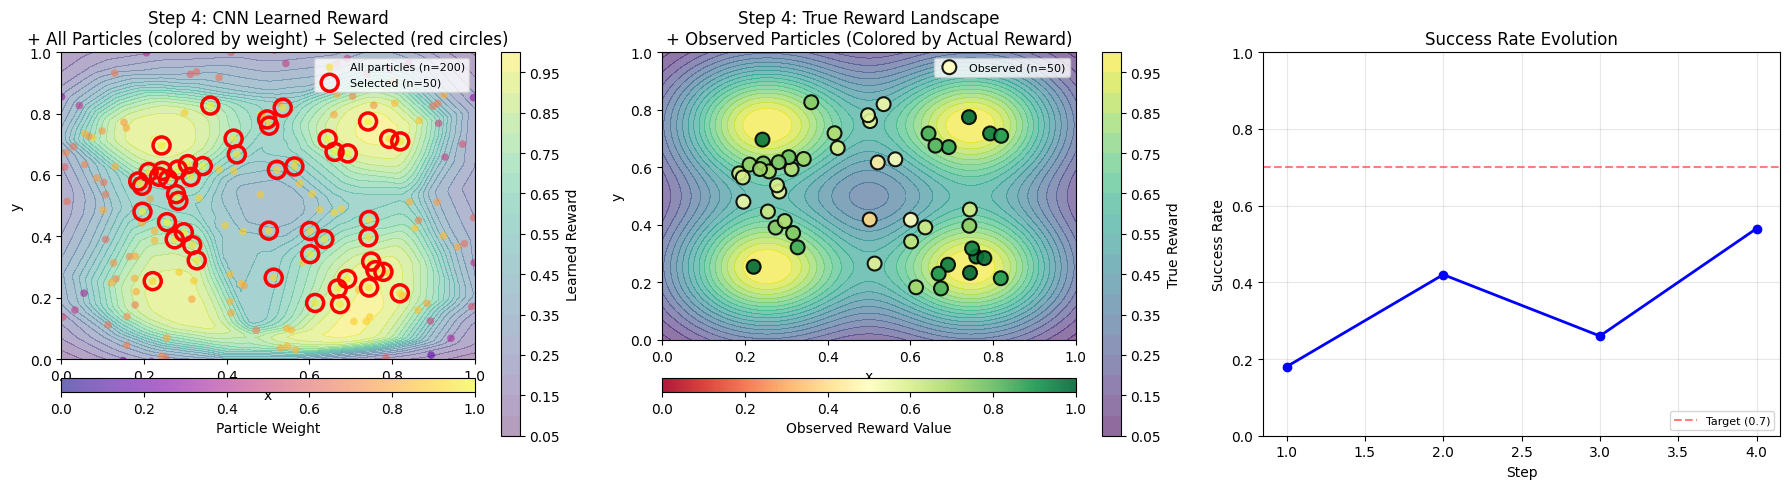

Step 4: Observed 50 particles | Avg Reward: 0.733 | Success: 27/50 (54.0%)
Step 4, Budget remaining: 300
  Gamma for this step: 0.0333
  Using 200 historical particles for diversity computation
    Selected weight range: [0.919, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 250 total observations...
    Final training loss: 0.000599


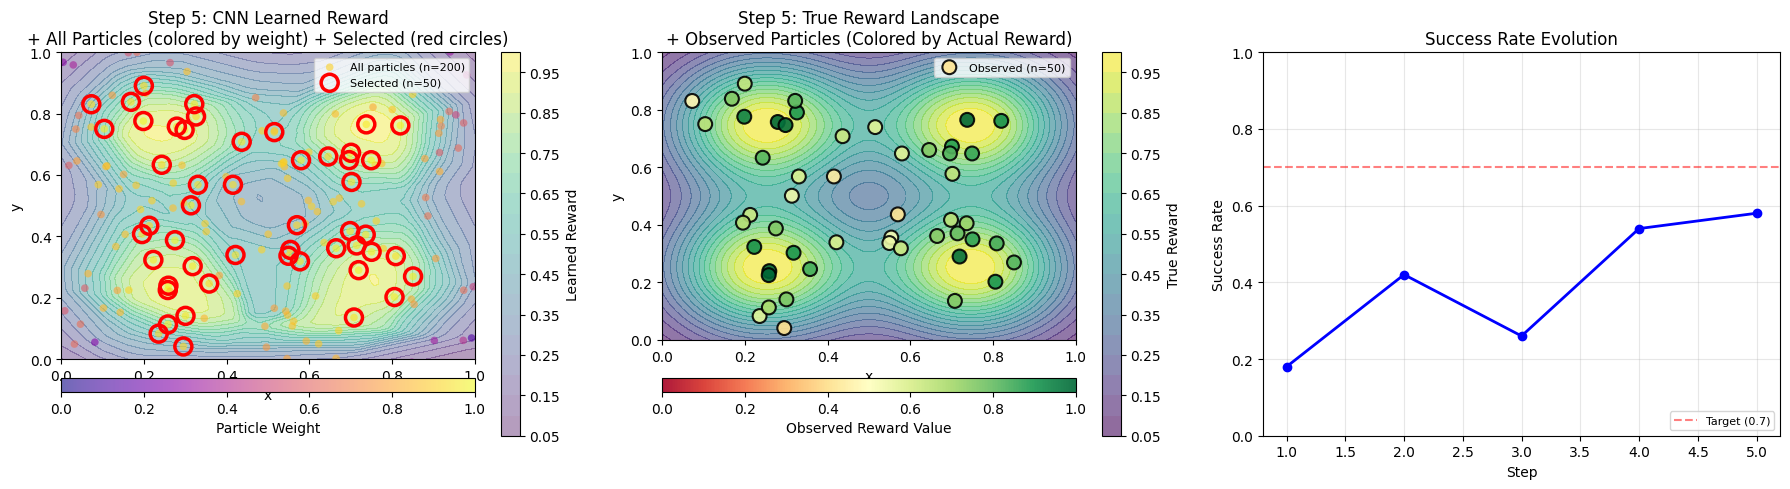

Step 5: Observed 50 particles | Avg Reward: 0.742 | Success: 29/50 (58.0%)
Step 5, Budget remaining: 250
  Gamma for this step: 0.0278
  Using 250 historical particles for diversity computation
    Selected weight range: [0.884, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 300 total observations...
    Final training loss: 0.000430


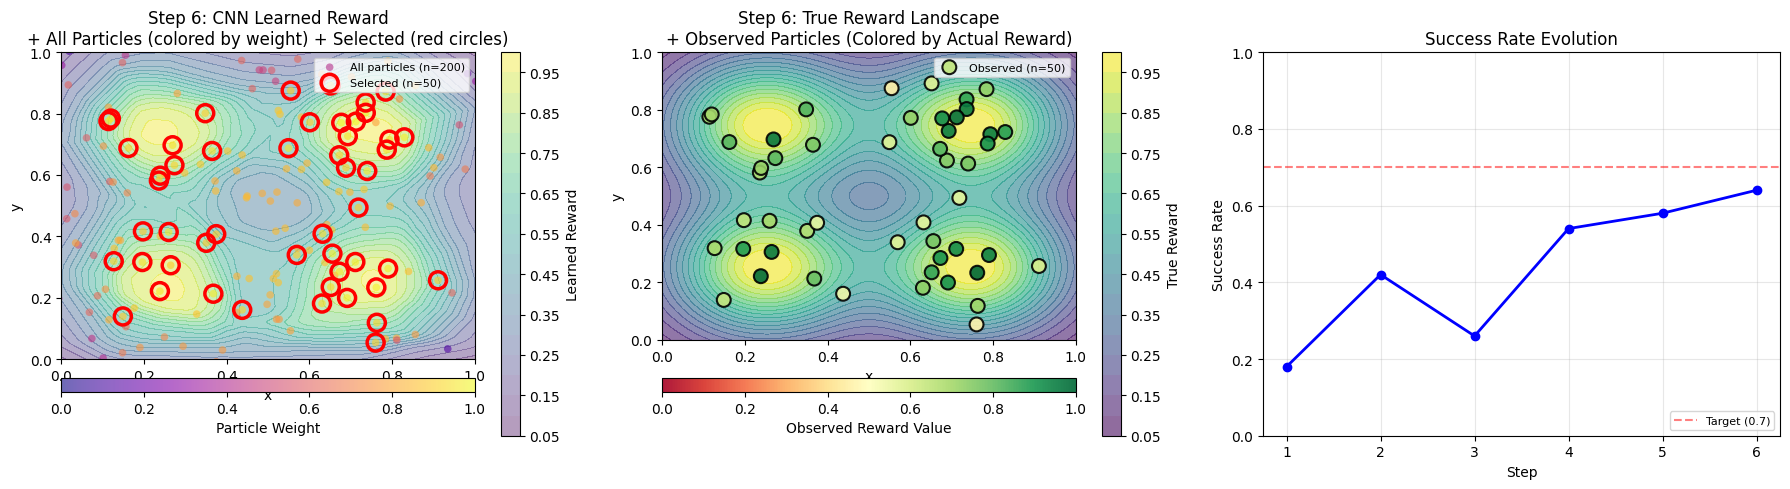

Step 6: Observed 50 particles | Avg Reward: 0.768 | Success: 32/50 (64.0%)
Step 6, Budget remaining: 200
  Gamma for this step: 0.0222
  Using 300 historical particles for diversity computation
    Selected weight range: [0.846, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 350 total observations...
    Final training loss: 0.000139


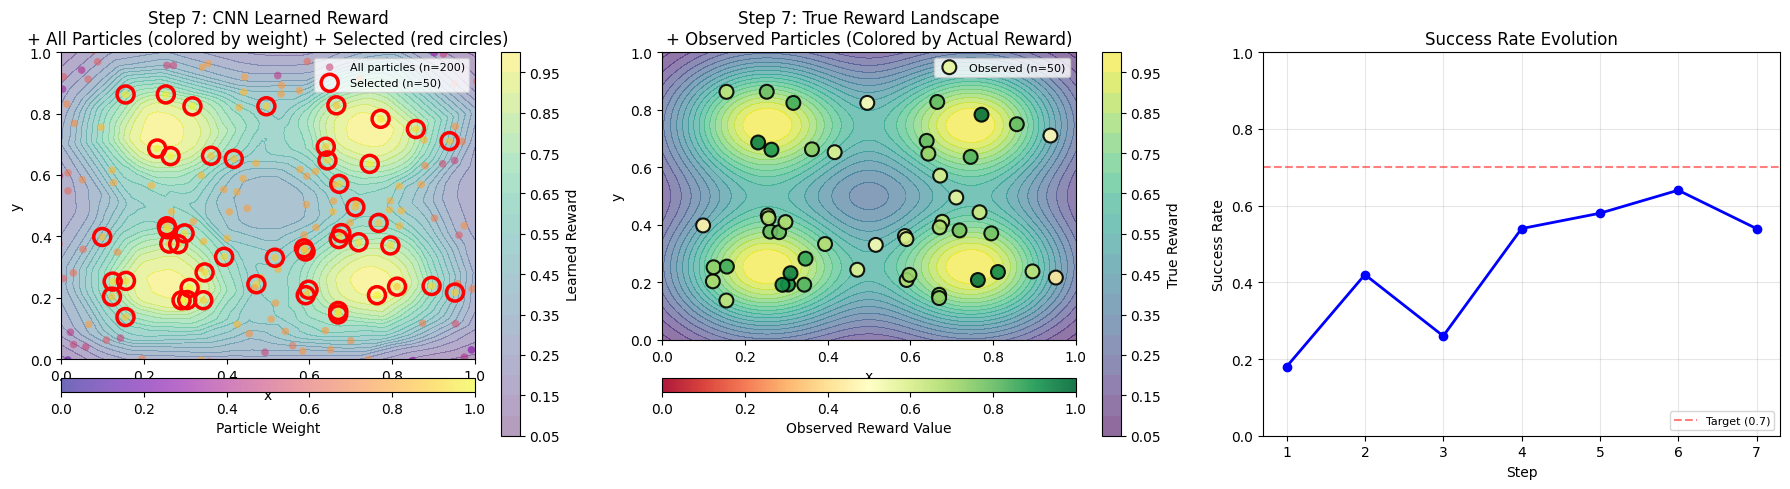

Step 7: Observed 50 particles | Avg Reward: 0.725 | Success: 27/50 (54.0%)
Step 7, Budget remaining: 150
  Gamma for this step: 0.0167
  Using 350 historical particles for diversity computation
    Selected weight range: [0.827, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 400 total observations...
    Final training loss: 0.000267


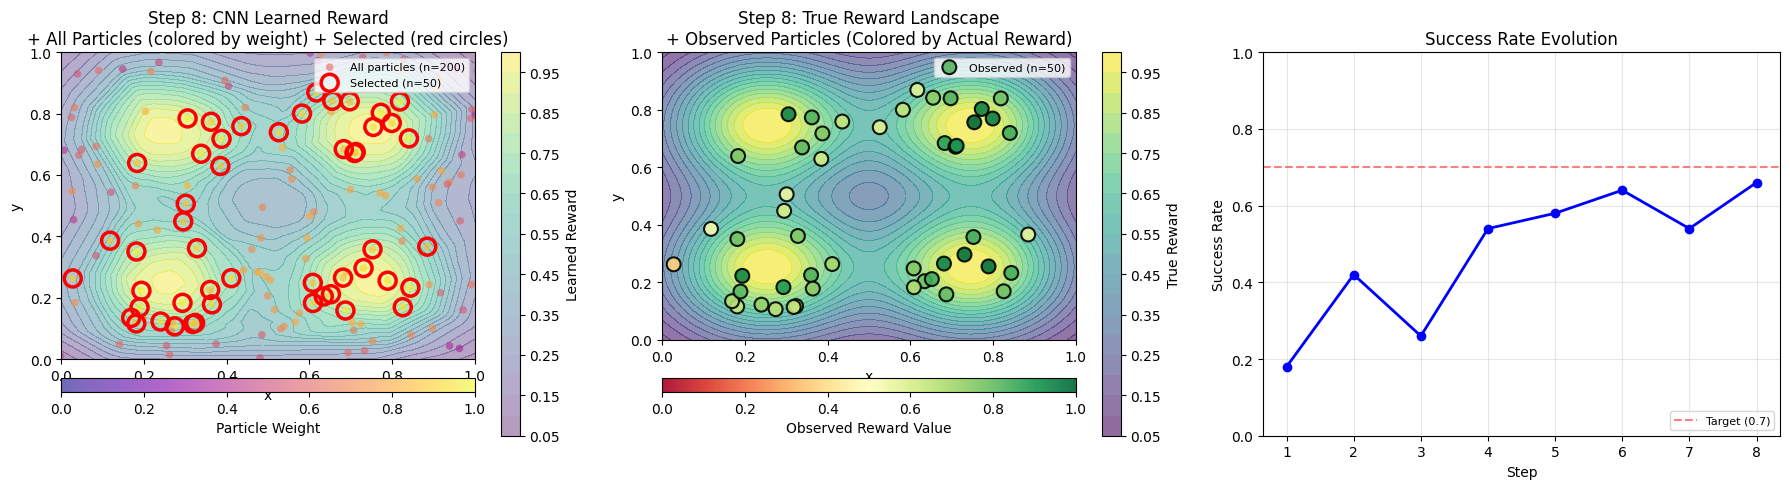

Step 8: Observed 50 particles | Avg Reward: 0.764 | Success: 33/50 (66.0%)
Step 8, Budget remaining: 100
  Gamma for this step: 0.0111
  Using 400 historical particles for diversity computation
    Selected weight range: [0.792, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 450 total observations...
    Final training loss: 0.000127


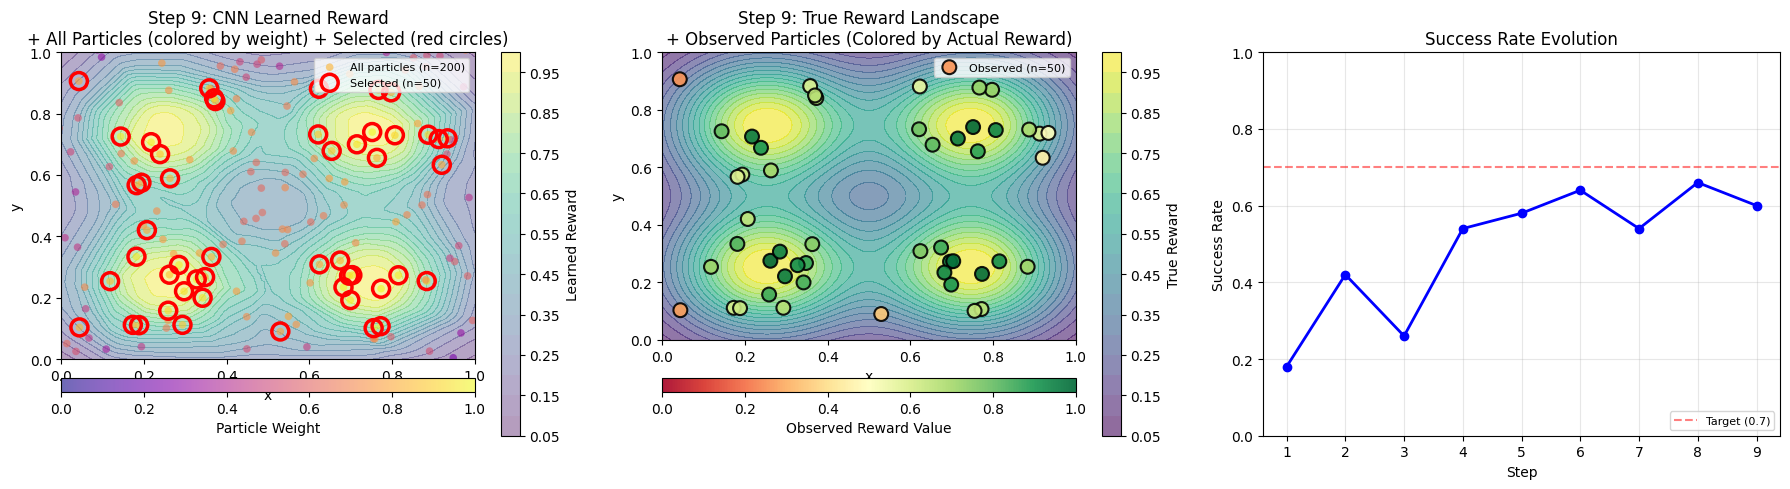

Step 9: Observed 50 particles | Avg Reward: 0.750 | Success: 30/50 (60.0%)
Step 9, Budget remaining: 50
  Gamma for this step: 0.0056
  Using 450 historical particles for diversity computation
    Selected weight range: [0.714, 1.000]
    All particles weight range: [0.000, 1.000]
  Training CNN on 500 total observations...
    Final training loss: 0.000098


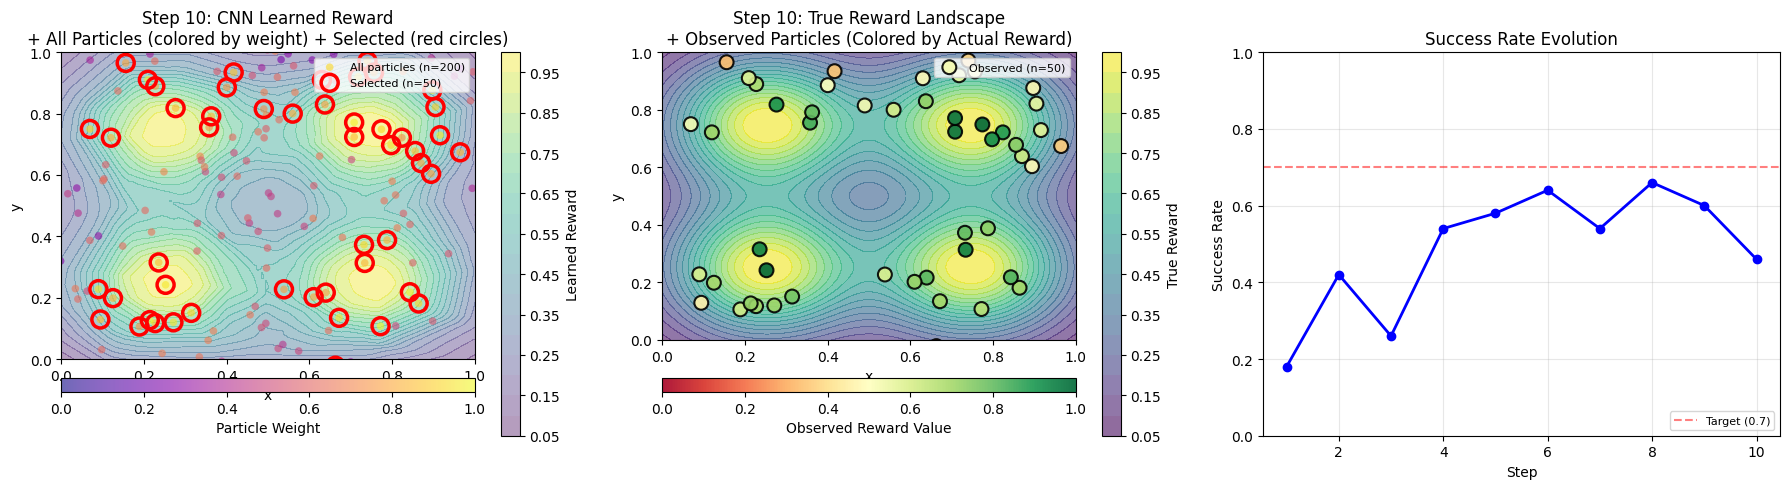

Step 10: Observed 50 particles | Avg Reward: 0.671 | Success: 23/50 (46.0%)

DIVERSITY-BASED EXPLORATION VISUALIZATION



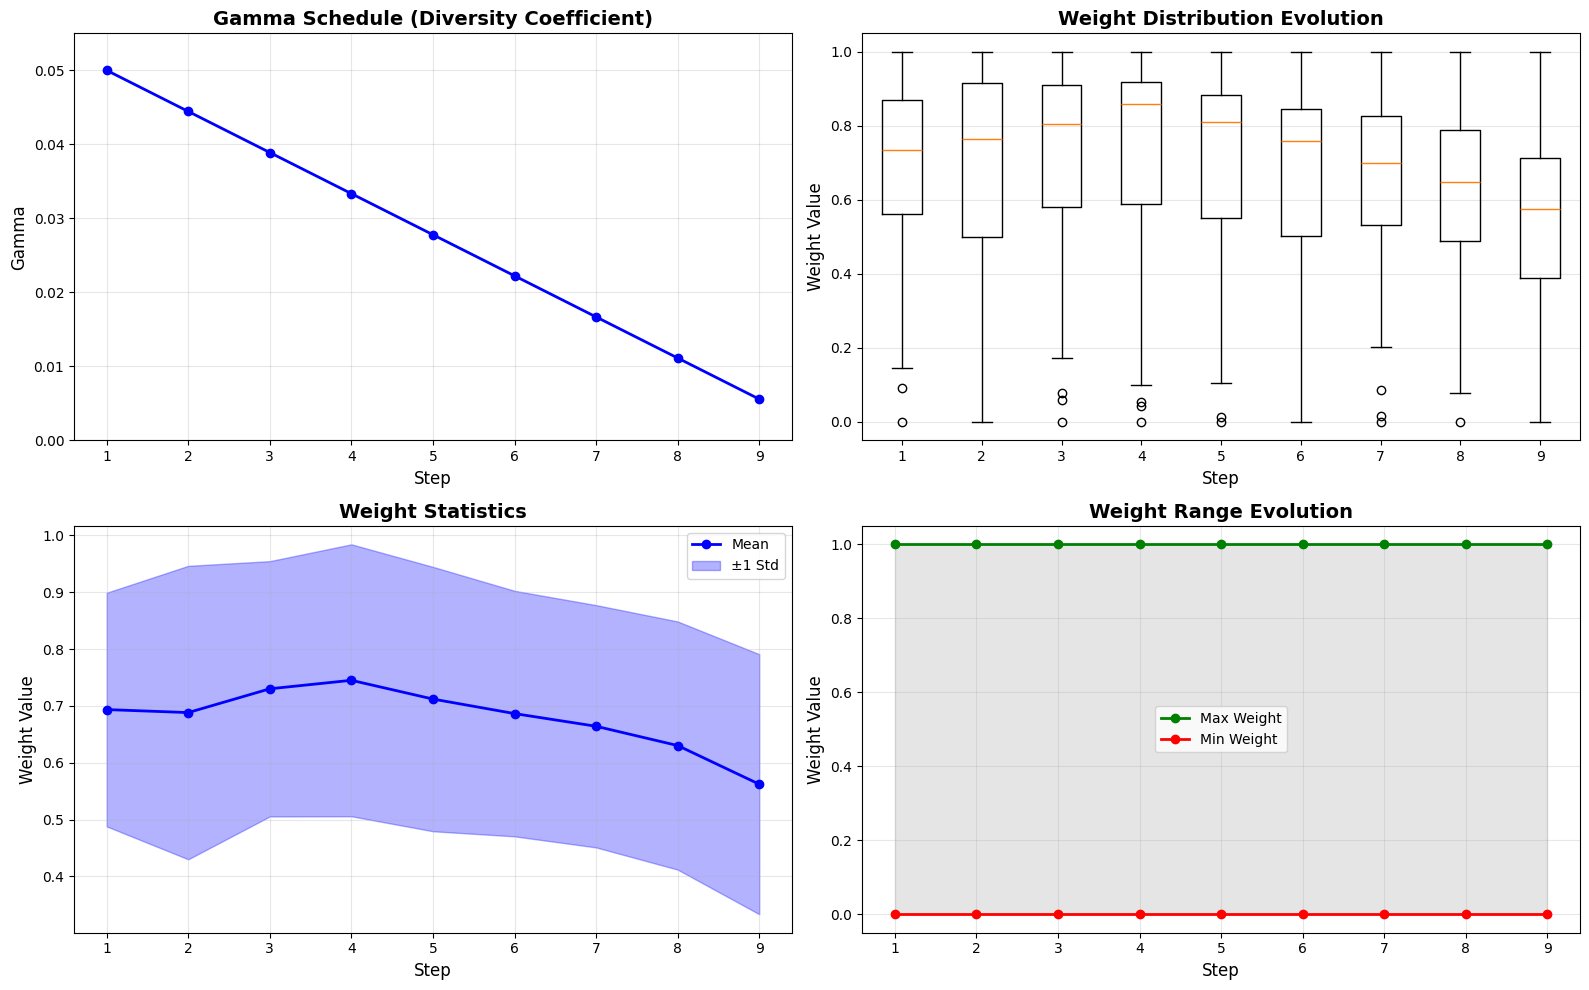


DIVERSITY-BASED EXPLORATION SUMMARY
Total steps (excluding cold start): 9
Gamma range: [0.006, 0.050]
Final gamma: 0.006
Always selected top-50 particles by weight


FINAL ANALYSIS
Final success rate: 46.0%
Max success rate achieved: 66.0%
Average success rate: 48.8%


In [66]:
# Experiment parameters
k_observe = 50
B = 500
n_particles = 200

# Use ONLY four optima reward function
reward_function_4optima = create_four_optima_reward_landscape

# VISUALIZE THE BASE MODEL DISTRIBUTION FIRST
visualize_base_model_distribution()

print("="*80)
print("TESTING: Base Model OPPOSITE to Reward (Worst Case Scenario)")
print("="*80 + "\n")

# ... rest of the code
print("Base model: Gaussian peak at CENTER (0.5, 0.5)")
print("Reward function: Four peaks at CORNERS (0.25, 0.25), etc.")
print("="*80 + "\n")

# Run with diversity-based exploration
results = budget_constrained_diffusion(
    k_observe, B, n_particles, 
    reward_fn=reward_function_4optima
)

(all_particles, all_weights, all_observed_particles, 
 all_observed_rewards, success_rates, 
 trained_network, trained_params, trained_opt_state, 
 gamma_history) = results

# Visualize diversity-based behavior
print("\n" + "="*80)
print("DIVERSITY-BASED EXPLORATION VISUALIZATION")
print("="*80 + "\n")
visualize_gamma_and_diversity(gamma_history, all_weights, k_observe)

# Final analysis
print("\n" + "="*80)
print("FINAL ANALYSIS")
print("="*80)
print(f"Final success rate: {success_rates[-1]:.1%}")
print(f"Max success rate achieved: {max(success_rates):.1%}")
print(f"Average success rate: {np.mean(success_rates):.1%}")